In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset.csv
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-test-dataset.csv
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9273.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/14127.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9292.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/11396.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/14260.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/4353.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/7968.png
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/6490.png
/kaggle/input/datasets/kmader/r

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

In [14]:
IMG_DIR = '/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset'
CSV_PATH = '/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset.csv'

# EDA

In [25]:
df = pd.read_csv(CSV_PATH)

print("Few Recored form dataset : ")
print(df.head())

print("Shape of dataset : ", df.shape)
print(f"\nMissing values:")
print(df.isnull().sum())

Few Recored form dataset : 
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False
Shape of dataset :  (12611, 3)

Missing values:
id         0
boneage    0
male       0
dtype: int64


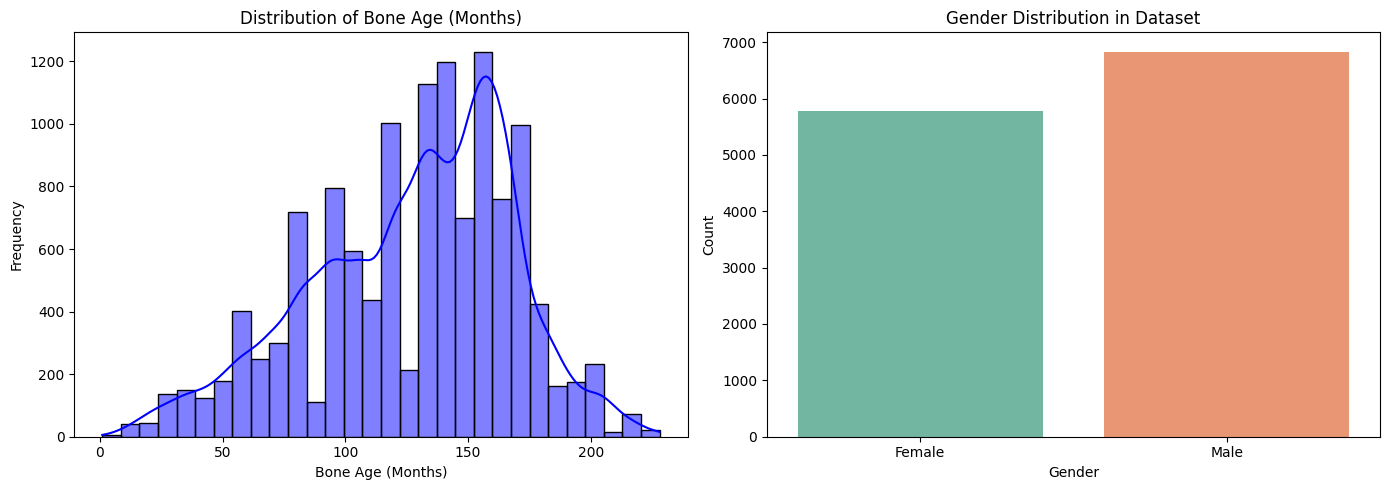

Total records: 12611


In [24]:
# Map Gender for readability in plots
df['gender'] = df['male'].apply(lambda x: 'Male' if str(x).lower() in ['true', '1', '1.0'] else 'Female')

plt.figure(figsize=(14, 5))

# Distribution of Bone Age
plt.subplot(1, 2, 1)
sns.histplot(df['boneage'], bins=30, kde=True, color='blue')
plt.title('Distribution of Bone Age (Months)')
plt.xlabel('Bone Age (Months)')
plt.ylabel('Frequency')

# Gender Split
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='gender', hue='gender', palette='Set2', legend=False)
plt.title('Gender Distribution in Dataset')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Total records: {len(df)}")

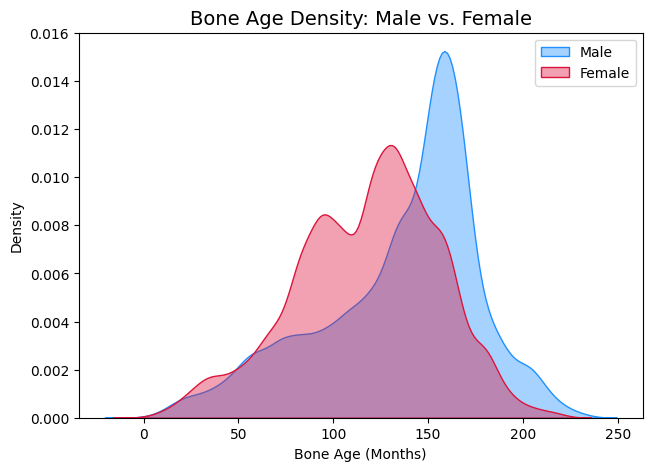

In [18]:
# Bone Age Distribution BY GENDER
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df[df['gender'] == 'Male'], x='boneage', fill=True, label='Male', alpha=0.4, color='dodgerblue')
sns.kdeplot(data=df[df['gender'] == 'Female'], x='boneage', fill=True, label='Female', alpha=0.4, color='crimson')
plt.title('Bone Age Density: Male vs. Female', fontsize=14)
plt.xlabel('Bone Age (Months)')
plt.ylabel('Density')
plt.legend()


Visualizing the Biological Progression of Bone Maturation:


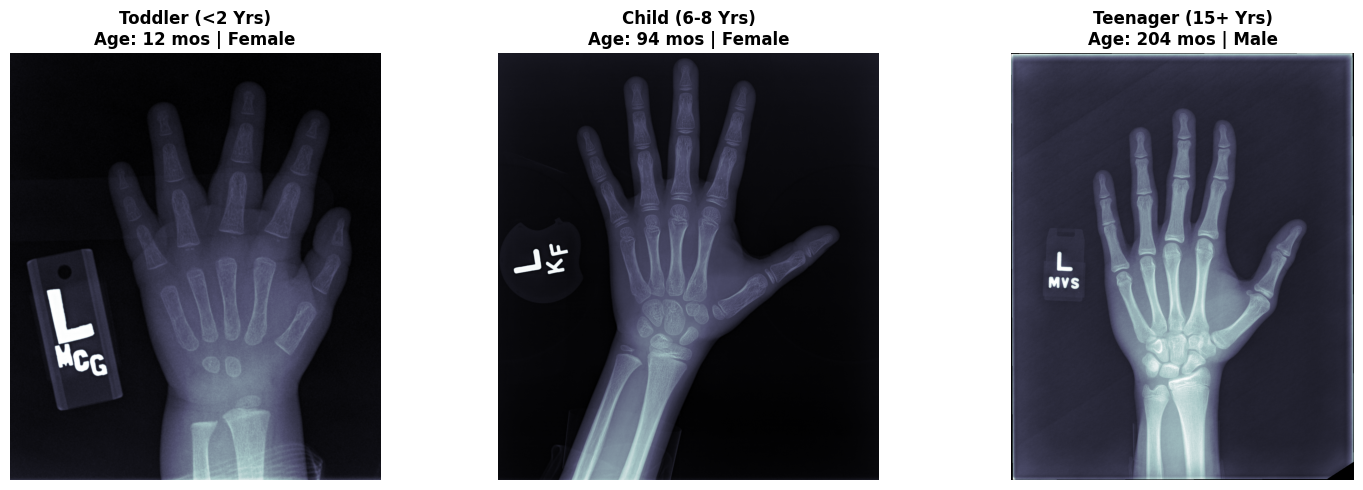

In [19]:
# Visualizing Skeletal Maturation (The "Wow" Factor)

print("\nVisualizing the Biological Progression of Bone Maturation:")

# Try to sample one from each age bucket safely
try:
    toddler = df[df['boneage'] <= 24].sample(1, random_state=42).iloc[0]
    child = df[(df['boneage'] > 72) & (df['boneage'] <= 96)].sample(1, random_state=42).iloc[0]
    teen = df[df['boneage'] >= 180].sample(1, random_state=42).iloc[0]
    
    samples = [
        ("Toddler (<2 Yrs)", toddler),
        ("Child (6-8 Yrs)", child),
        ("Teenager (15+ Yrs)", teen)
    ]
    
    plt.figure(figsize=(15, 5))
    
    for i, (label, row) in enumerate(samples):
        img_path = os.path.join(IMG_DIR, f"{row['id']}.png")
        
        plt.subplot(1, 3, i + 1)
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            plt.imshow(img, cmap='bone') # Using the 'bone' colormap for better X-ray contrast
            plt.title(f"{label}\nAge: {row['boneage']} mos | {row['gender']}", fontsize=12, fontweight='bold')
            plt.axis('off')
        else:
            plt.title("Image Missing", color='red')
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Could not load progression images. Ensure data is cleaned first.")